In [12]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ejlok1_toronto_emotional_speech_set_tess_path = kagglehub.dataset_download('ejlok1/toronto-emotional-speech-set-tess')

print('Data source import complete.')


Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.
Data source import complete.


In [13]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [14]:
paths = []
labels = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        label = filename.split('_')[-1]
        label = label.split('.')[0]
        labels.append(label.lower())
    if len(paths) == 2800:
        break
print('Dataset is Loaded')

Dataset is Loaded


In [15]:
len(paths)

2800

In [16]:
paths[:5]

['/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_youth_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_near_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_search_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_pick_fear.wav']

In [17]:
labels[:5]

['fear', 'fear', 'fear', 'fear', 'fear']

In [18]:
## Create a dataframe
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,/kaggle/input/toronto-emotional-speech-set-tes...,fear
1,/kaggle/input/toronto-emotional-speech-set-tes...,fear
2,/kaggle/input/toronto-emotional-speech-set-tes...,fear
3,/kaggle/input/toronto-emotional-speech-set-tes...,fear
4,/kaggle/input/toronto-emotional-speech-set-tes...,fear


In [19]:
df['label'].value_counts()

,count
label,
fear,400
angry,400
disgust,400
neutral,400
sad,400
ps,400
happy,400


# Exploratory Data Analysis


<Axes: xlabel='label', ylabel='count'>

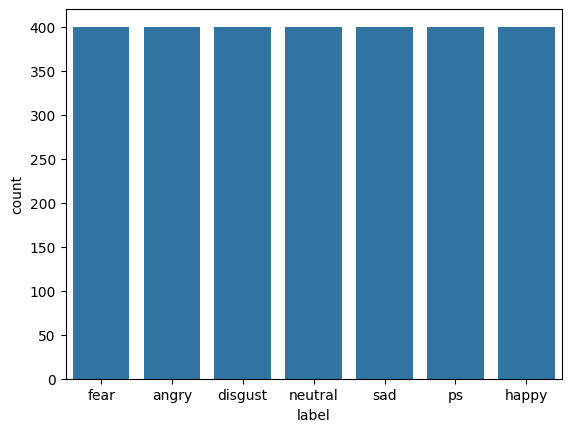

In [20]:
sns.countplot(data=df, x='label')

In [21]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

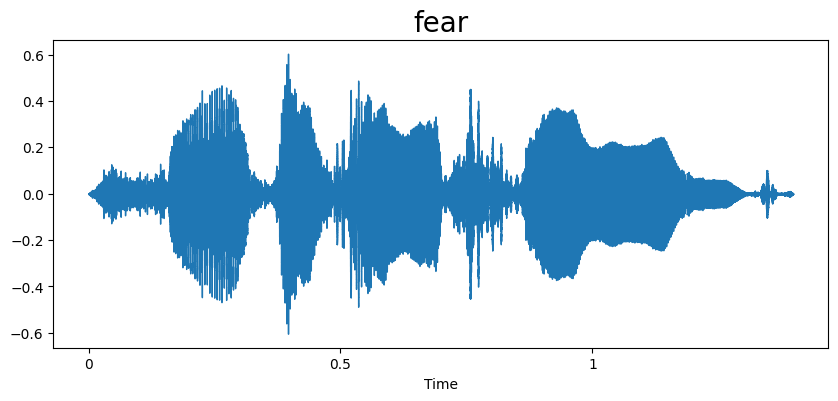

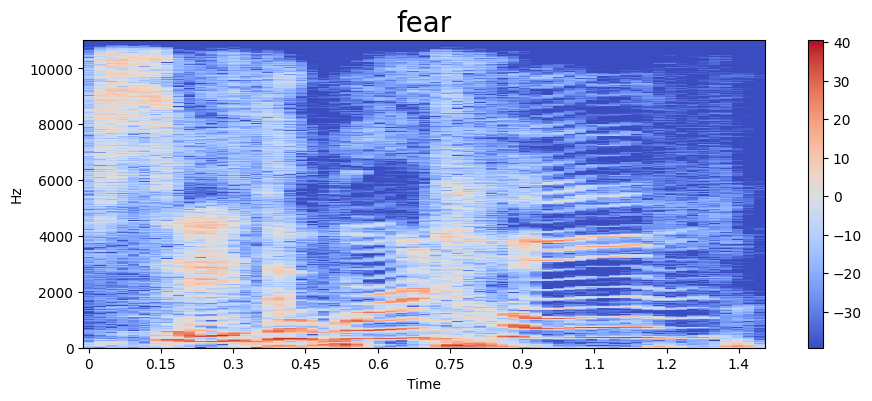

In [22]:
emotion = 'fear'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

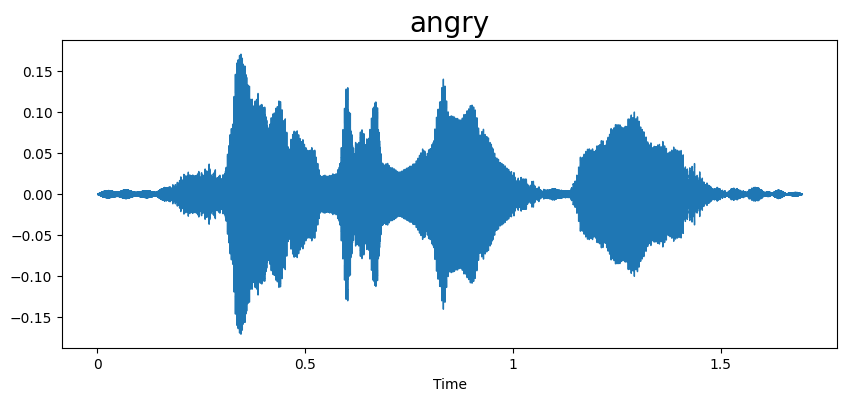

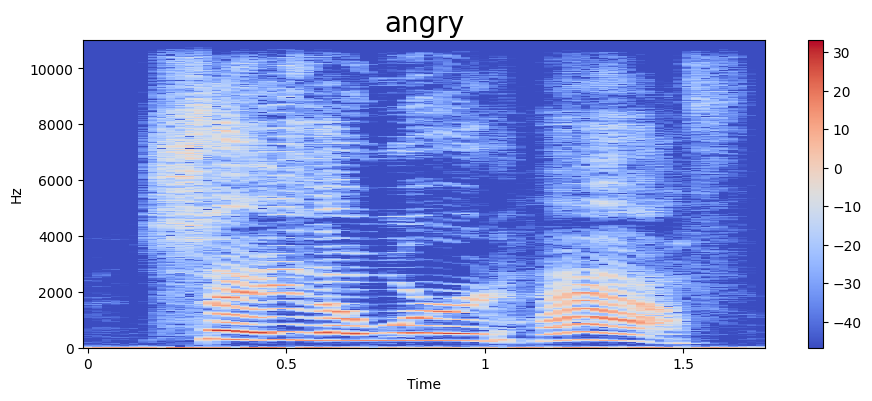

In [23]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

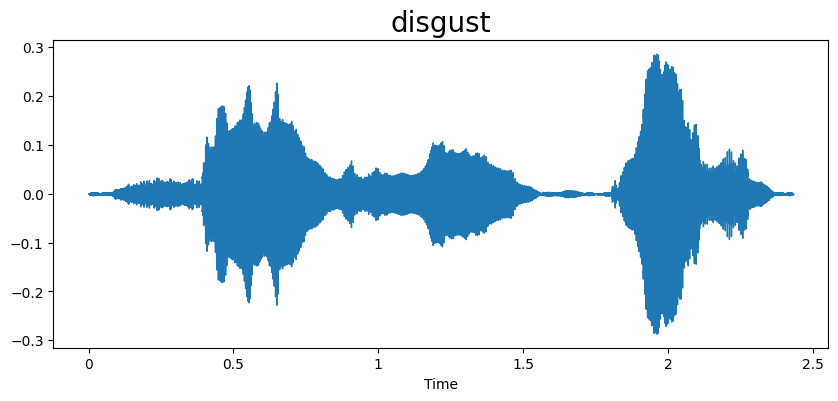

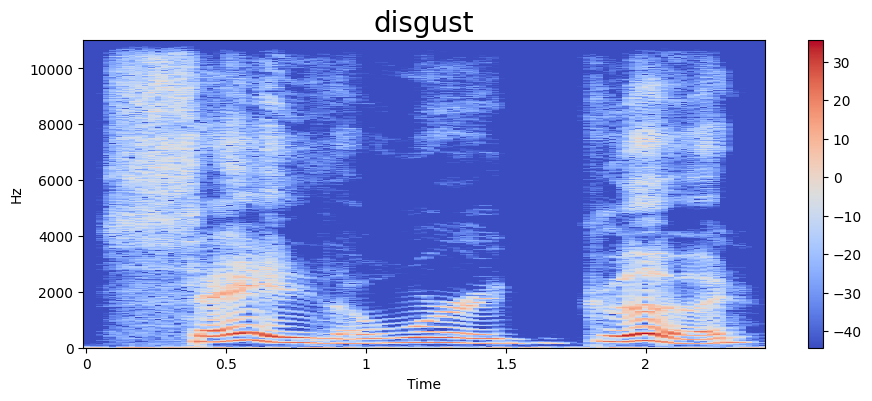

In [24]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

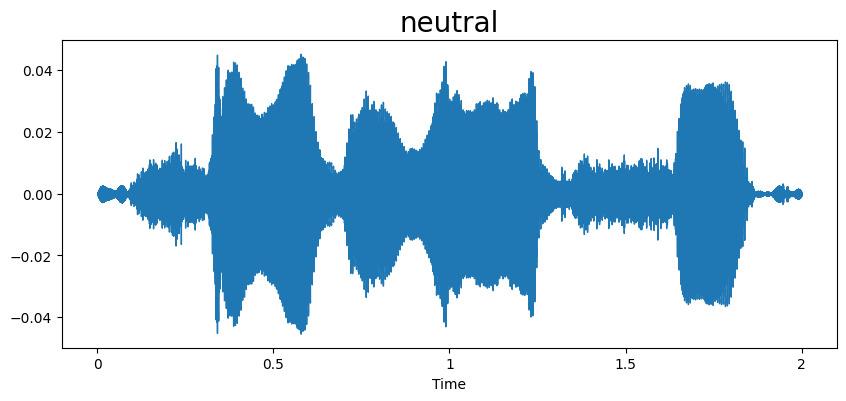

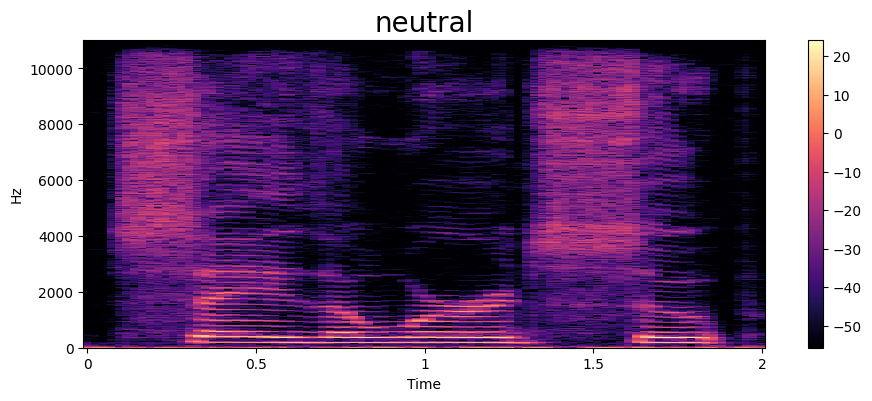

In [25]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

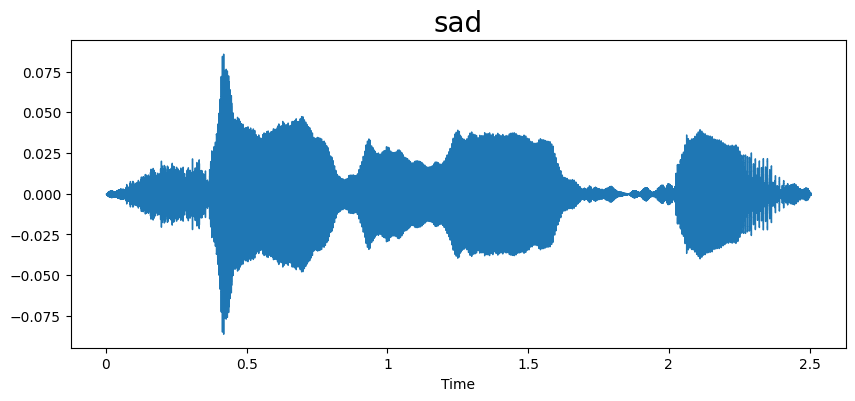

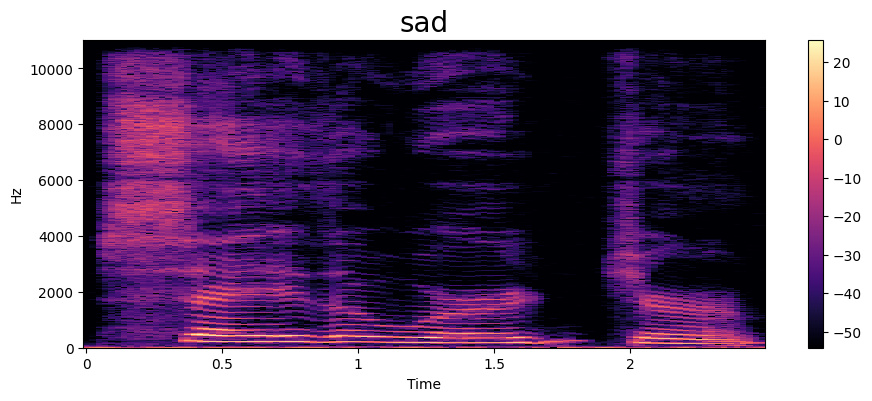

In [26]:
emotion = 'sad'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

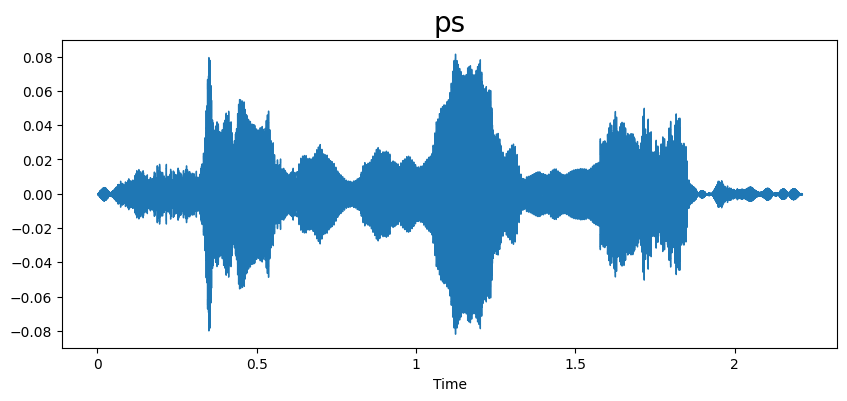

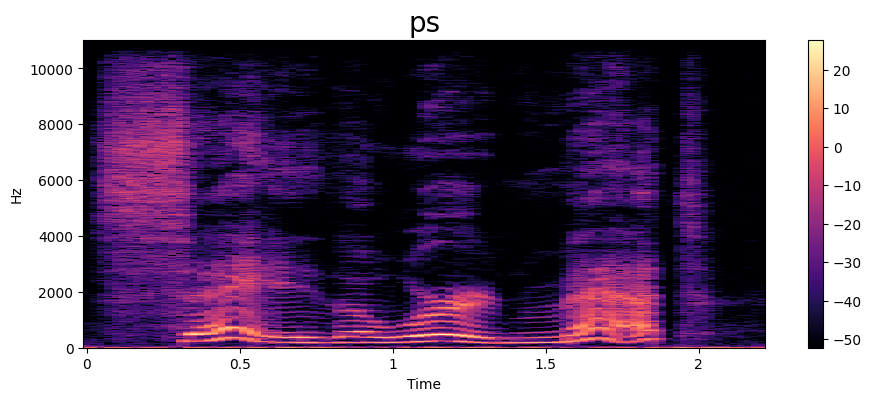

In [27]:
emotion = 'ps'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

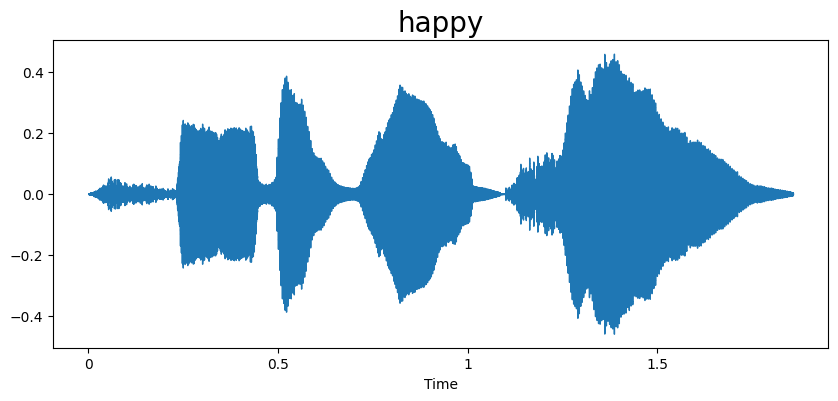

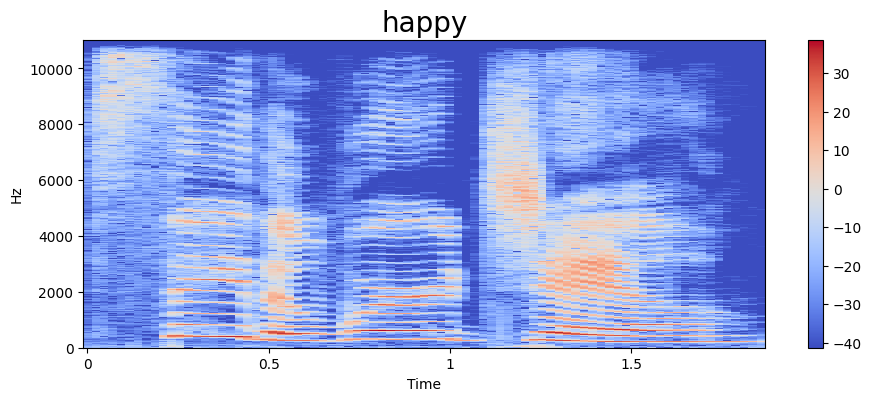

In [28]:
emotion = 'happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

# Feature Extraction

In [29]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [30]:
extract_mfcc(df['speech'][0])

array([-285.73727  ,   85.78295  ,   -2.1689117,   22.12553  ,
        -14.757396 ,   11.051346 ,   12.412449 ,   -3.000262 ,
          1.0844991,   11.078272 ,  -17.41966  ,   -8.093214 ,
          6.5879736,   -4.2209525,   -9.15508  ,    3.5214806,
        -13.186381 ,   14.078853 ,   19.66973  ,   22.725618 ,
         32.57464  ,   16.325035 ,   -3.8427284,    0.8962968,
        -11.239262 ,    6.653461 ,   -2.5883696,   -7.7140164,
        -10.941657 ,   -2.4007547,   -5.2812862,    4.271157 ,
        -11.202218 ,   -9.024621 ,   -3.6669848,    4.869744 ,
         -1.6027985,    2.5600514,   11.454374 ,   11.233449 ],
      dtype=float32)

In [31]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [32]:
X_mfcc

,speech
0,"[-285.73727, 85.78295, -2.1689117, 22.12553, -..."
1,"[-348.34332, 35.193233, -3.841328, 14.658875, ..."
2,"[-340.11435, 53.796444, -14.267782, 20.884031,..."
3,"[-306.63422, 21.259708, -4.4110823, 6.487155, ..."
4,"[-344.7548, 46.329193, -24.171413, 19.392921, ..."
...,...
2795,"[-374.3952, 60.864998, 0.025059033, 8.431058, ..."
2796,"[-313.9648, 39.847843, -5.6493053, -3.867575, ..."
2797,"[-357.54886, 77.88605, -15.224756, 2.1946332, ..."
2798,"[-353.1474, 101.68391, -14.175898, -12.037377,..."


In [33]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [34]:
## input split
X = np.expand_dims(X, -1)
X.shape

(2800, 40, 1)

In [35]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])

In [36]:
y = y.toarray()

In [37]:
y.shape

(2800, 7)

# Create the LSTM Model


In [38]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40,1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Train the model
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=64)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.4944 - loss: 1.4446 - val_accuracy: 0.0893 - val_loss: 2.8508
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.8171 - loss: 0.5093 - val_accuracy: 0.2446 - val_loss: 2.5295
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.9201 - loss: 0.2630 - val_accuracy: 0.3393 - val_loss: 2.8370
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9609 - loss: 0.1384 - val_accuracy: 0.4089 - val_loss: 2.7409
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.9613 - loss: 0.1218 - val_accuracy: 0.3429 - val_loss: 2.6790
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.9613 - loss: 0.1378 - val_accuracy: 0.3018 - val_loss: 3.0540
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.9548 - loss: 0.1397 - val_accuracy: 0.3625 - val_loss: 2.6848
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.9691 - loss: 0.0919 - val_accuracy: 0.

In [40]:
# best val accuracy: 72.32
# use checkpoint to save the best val accuracy model
# adjust learning rate for slow convergence

# Plot the results

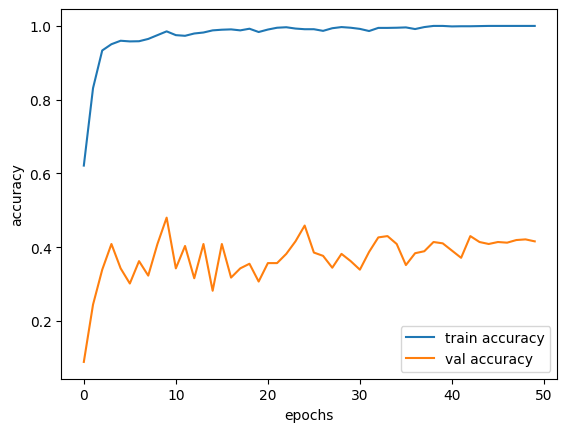

In [41]:
epochs = list(range(50))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

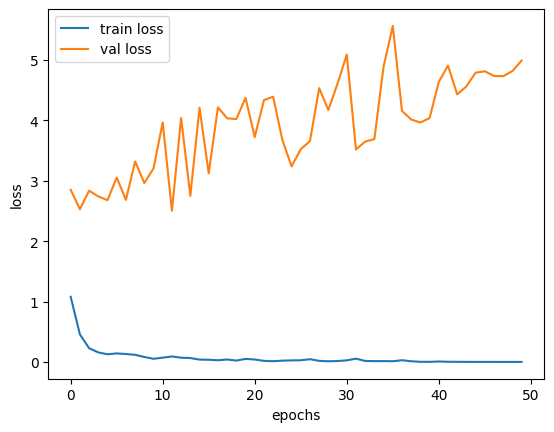

In [42]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')
plt.plot(epochs, val_loss, label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [44]:
model.save("emotion_model.keras")

In [45]:
import pickle

# Define the filename for the pickle file
pickle_filename = "emotion_model.pkl"

# Save the model to a pickle file
with open(pickle_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved as {pickle_filename}")

Model saved as emotion_model.pkl


### Note on saving Keras models:

While saving a Keras model with `pickle` might seem straightforward, it's generally **not the recommended approach**.

**Reasons to prefer `model.save()` or `tf.keras.models.save_model()`:**

1.  **Portability and Robustness:** Keras models saved using `model.save()` (which typically defaults to the Keras v3 format or older HDF5 format) are more robust and portable across different environments and Keras/TensorFlow versions. They store the entire model: architecture, weights, and optimizer state.
2.  **Custom Objects:** If your model includes custom layers, activation functions, or other custom objects, `pickle` might fail to serialize them correctly or lead to issues upon loading. Keras's native saving mechanism handles these cases by allowing you to register custom objects.
3.  **Future Compatibility:** Keras's native saving formats are designed to maintain better forward and backward compatibility.

**When `pickle` might seem appropriate (but still not ideal):**

*   For very simple models without custom components.
*   If you are primarily interested in pickling the Python object itself rather than a deployable, robust model format.

For most Keras applications, it's best to stick to `model.save("model.keras")` or `model.save("model.h5")` for the older HDF5 format.

In [50]:
def predict_emotion_from_audio(audio_file_path):
    # Preprocess the audio file
    processed_features = preprocess_audio_for_prediction(audio_file_path)

    # Expand dimensions for model input (batch size of 1)
    model_input = np.expand_dims(processed_features, axis=0)

    # Make prediction
    raw_predictions = loaded_model.predict(model_input)

    # Get the predicted label index
    predicted_label_index = np.argmax(raw_predictions)

    # Get the emotion labels from the OneHotEncoder
    emotion_labels = enc.categories_[0]

    # Get the predicted emotion label
    predicted_emotion = emotion_labels[predicted_label_index]

    return predicted_emotion

print("Function `predict_emotion_from_audio` defined.")

Function `predict_emotion_from_audio` defined.


In [51]:
# Example usage:
# You would replace 'sample_audio_path' with the actual path to your uploaded audio file.
# For demonstration, we'll use the same sample audio as before.

# Assuming `sample_audio_path` is defined from previous steps
predicted_emotion_for_new_audio = predict_emotion_from_audio(sample_audio_path)
print(f"The predicted emotion for the audio file '{sample_audio_path}' is: {predicted_emotion_for_new_audio}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
The predicted emotion for the audio file '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav' is: fear


# Task
The final goal is to define a function to load and preprocess a new audio file, use the trained model to predict the emotion from the audio, and then display the predicted emotion to the user. This will include extracting MFCC features, reshaping the data for model input, and converting the model's output to a human-readable emotion label.

## Load and Preprocess New Audio

### Subtask:
Define a function to load a new audio file, extract its MFCC features, and prepare it for model prediction. This will be similar to the existing `extract_mfcc` function, but will also include the necessary reshaping for the model input.


**Reasoning**:
The subtask requires defining a function to preprocess a new audio file for prediction, including loading the audio, extracting MFCC features, and reshaping them for the LSTM model input.



In [46]:
def preprocess_audio_for_prediction(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    # Reshape the MFCC features to (40, 1) to match the model's expected input shape for a single sample
    mfcc_reshaped = np.expand_dims(mfcc, axis=-1)
    return mfcc_reshaped

print("Function `preprocess_audio_for_prediction` defined.")

Function `preprocess_audio_for_prediction` defined.


## Predict Emotion from Audio

### Subtask:
Use the trained model to predict the emotion from the preprocessed audio features. The input to the model should be the MFCC features of the new audio file, expanded to the correct dimensions.


**Reasoning**:
The subtask requires using the trained model for prediction. First, I need to load the saved Keras model, then prepare a sample audio input by preprocessing it and expanding its dimensions to match the model's expected input shape for batch prediction. Finally, I will use the loaded model to make a prediction on the prepared input.



**Reasoning**:
The previous attempt to load `emotion_model.keras` failed because the file was not found. Reviewing the available files in the kernel, it is clear that `emotion_model.pkl` exists, which was created using `pickle.dump()`. Therefore, the model should be loaded using `pickle.load()` instead of `tf.keras.models.load_model()`.



In [52]:
audio_file_to_predict = '/content/voice_audio.mp3'
predicted_emotion = predict_emotion_from_audio(audio_file_to_predict)
print(f"The predicted emotion for '{audio_file_to_predict}' is: {predicted_emotion}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
The predicted emotion for '/content/voice_audio.mp3' is: disgust


In [53]:
audio_file_to_predict_2 = '/content/voice_audio_1.mp3'
predicted_emotion_2 = predict_emotion_from_audio(audio_file_to_predict_2)
print(f"The predicted emotion for '{audio_file_to_predict_2}' is: {predicted_emotion_2}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
The predicted emotion for '/content/voice_audio_1.mp3' is: fear


In [73]:
import tensorflow as tf
import pickle

# 1. Load the trained Keras model
# Using pickle.load() as emotion_model.keras was not found, but emotion_model.pkl was saved.
with open('emotion_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
print("Model loaded successfully from pickle file.")

# 2. Select a sample audio file path
sample_audio_path = df['speech'][0]
print(f"Selected sample audio: {sample_audio_path}")

# 3. Preprocess this selected audio file
processed_audio_features = preprocess_audio_for_prediction(sample_audio_path)
print(f"Processed audio features shape: {processed_audio_features.shape}")

# 4. Expand the dimensions for batch prediction
model_input = np.expand_dims(processed_audio_features, axis=0)
print(f"Model input shape: {model_input.shape}")

# 5. Use the loaded_model.predict() method to get the raw predictions
raw_predictions = loaded_model.predict(model_input)
print("Raw predictions:")
print(raw_predictions)

Model loaded successfully from pickle file.
Selected sample audio: /kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav
Processed audio features shape: (40, 1)
Model input shape: (1, 40, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Raw predictions:
[[8.2423250e-09 5.0737448e-10 9.9999976e-01 2.0043649e-08 2.8750290e-07
  4.6876875e-10 6.2854666e-10]]


**Reasoning**:
Now that the raw predictions are available, the next step is to convert these numerical predictions into human-readable emotion labels. This involves finding the index of the highest probability in the `raw_predictions` array and then using the `OneHotEncoder` object (`enc`) to map this index back to the original emotion categories. Additionally, it's good practice to display the original audio's label for comparison.



In [75]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Get all unique labels from the original DataFrame
all_labels = np.array(df['label'].unique()).reshape(-1, 1)

# Re-initialize and fit the OneHotEncoder to ensure it has the correct categories
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(all_labels)

predicted_label_index = np.argmax(raw_predictions)

# Get the emotion labels from the OneHotEncoder
emotion_labels = enc.categories_[0]

# Get the predicted emotion label
predicted_emotion = emotion_labels[predicted_label_index]

print(f"Predicted emotion: {predicted_emotion}")

# Print the actual emotion from the DataFrame for comparison
actual_emotion = df['label'][df['speech'] == sample_audio_path].iloc[0]
print(f"Actual emotion: {actual_emotion}")

Predicted emotion: fear
Actual emotion: fear
